# 1. Analyse et comprehension des donnees

Presenter le dataset, verifier les valeurs manquantes, detecter les valeurs aberrantes et observer la distribution des variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

df = pd.read_csv('Data/Concrete Compressive Strength.csv')
target_column = 'Concrete compressive strength '

In [2]:
display(df.head())
print('Dimensions:', df.shape)
display(df.dtypes.to_frame(name='type'))
print('Variable cible:', target_column)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


Dimensions: (1030, 9)


,type
Cement,float64
Blast Furnace Slag,float64
Fly Ash,float64
Water,float64
Superplasticizer,float64
Coarse Aggregate,float64
Fine Aggregate,float64
Age (day),int64
Concrete compressive strength,float64


Variable cible: Concrete compressive strength 


In [3]:
missing_values = df.isna().sum().to_frame(name='valeurs_manquantes')
display(missing_values)
print('Total valeurs manquantes:', int(missing_values['valeurs_manquantes'].sum()))

,valeurs_manquantes
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


Total valeurs manquantes: 0


,nombre_de_valeurs_aberrantes
Age (day),59
Superplasticizer,10
Water,9
Fine Aggregate,5
Concrete compressive strength,4
Blast Furnace Slag,2
Cement,0
Fly Ash,0
Coarse Aggregate,0


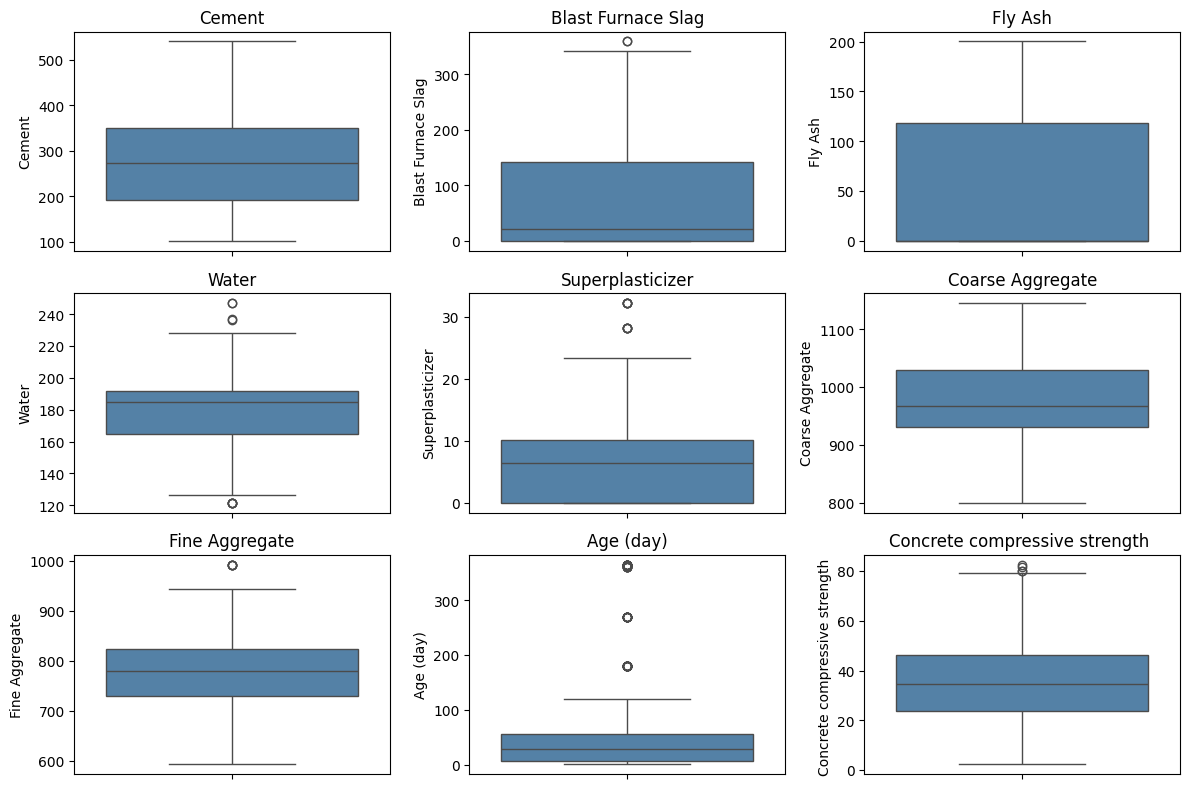

In [4]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
q1 = df[numeric_columns].quantile(0.25)
q3 = df[numeric_columns].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_counts = ((df[numeric_columns] < lower_bound) | (df[numeric_columns] > upper_bound)).sum().sort_values(ascending=False)
display(outlier_counts.to_frame(name='nombre_de_valeurs_aberrantes'))
plt.figure(figsize=(12, 8))
for i, column in enumerate(numeric_columns, start=1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column], color='steelblue')
    plt.title(column)
plt.tight_layout()
plt.show()

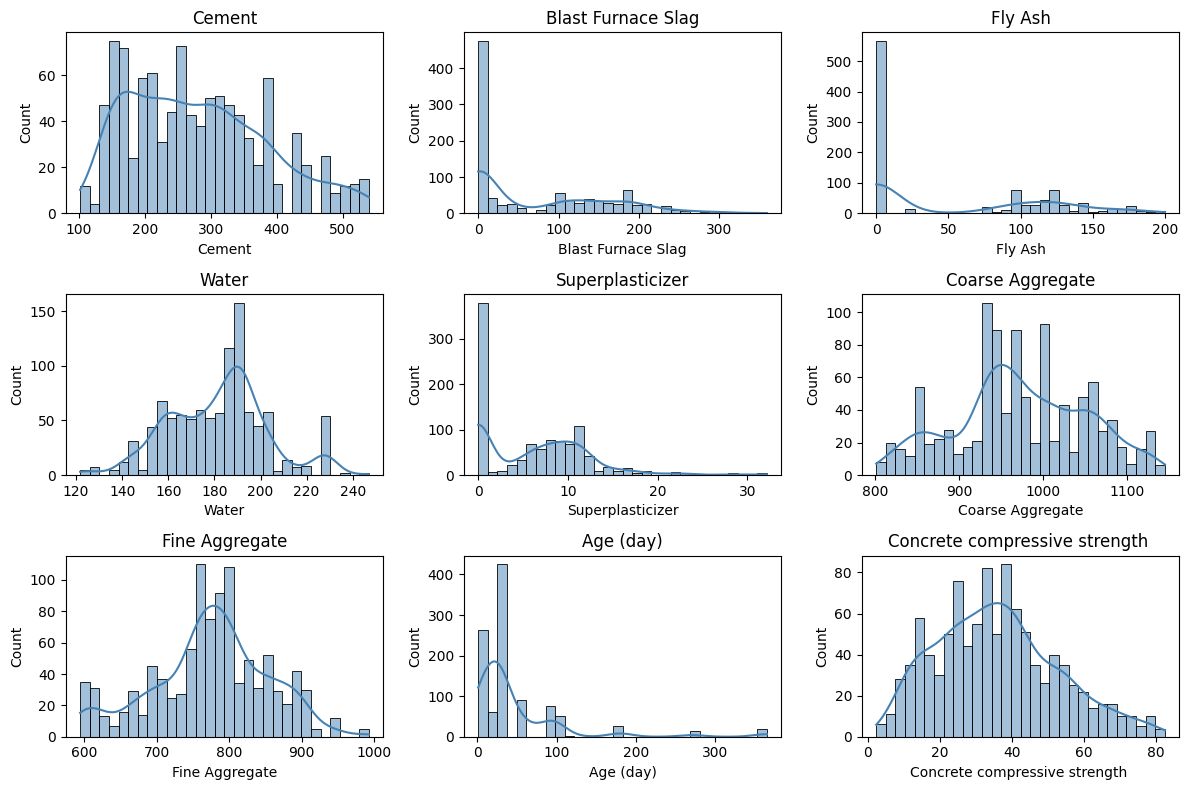

In [5]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns, start=1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], kde=True, color='steelblue', bins=30)
    plt.title(column)
plt.tight_layout()
plt.show()

# 2. Pretraitement des donnees

Traitement des valeurs manquantes, encodage des variables categorielle si elles existent, normalisation si necessaire, puis separation Train / Test avec validation croisee.

In [6]:
df_clean = df.copy()
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if df_clean.isna().sum().sum() > 0:
    df_clean[numeric_features] = df_clean[numeric_features].fillna(df_clean[numeric_features].median())
categorical_features = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_features:
    df_clean = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Variables categorielle encodees:', categorical_features if categorical_features else 'Aucune')
print('Taille train:', X_train.shape)
print('Taille test:', X_test.shape)

Variables categorielle encodees: Aucune
Taille train: (824, 8)
Taille test: (206, 8)


In [7]:
linear_model = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
linear_cv_scores = cross_val_score(linear_model, X_train, y_train, cv=5, scoring='r2')
print('Validation croisee R2 - regression lineaire:', linear_cv_scores)
print('Moyenne CV R2 - regression lineaire:', linear_cv_scores.mean())

Validation croisee R2 - regression lineaire: [0.56305499 0.5256709  0.70475826 0.63142728 0.54775967]
Moyenne CV R2 - regression lineaire: 0.5945342206290247


In [8]:
nonlinear_model = RandomForestRegressor(n_estimators=300, random_state=42)
nonlinear_cv_scores = cross_val_score(nonlinear_model, X_train, y_train, cv=5, scoring='r2')
print('Validation croisee R2 - regression non lineaire:', nonlinear_cv_scores)
print('Moyenne CV R2 - regression non lineaire:', nonlinear_cv_scores.mean())

Validation croisee R2 - regression non lineaire: [0.892641   0.91176792 0.91243499 0.91094545 0.91327161]
Moyenne CV R2 - regression non lineaire: 0.9082121952910317


# 3. Modelisation

Application des deux modeles demandes: regression lineaire et regression non lineaire.

In [9]:
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
nonlinear_model.fit(X_train, y_train)
nonlinear_predictions = nonlinear_model.predict(X_test)

# 4. Evaluation des modeles

Calcul du MSE et du R2 pour chaque modele.

In [10]:
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)
nonlinear_mse = mean_squared_error(y_test, nonlinear_predictions)
nonlinear_r2 = r2_score(y_test, nonlinear_predictions)
results = pd.DataFrame({
    'Modele': ['Regression lineaire', 'Regression non lineaire'],
    'MSE': [linear_mse, nonlinear_mse],
    'R2': [linear_r2, nonlinear_r2],
    'CV_R2_moyen': [linear_cv_scores.mean(), nonlinear_cv_scores.mean()],
    'CV_R2_ecart_type': [linear_cv_scores.std(), nonlinear_cv_scores.std()]
}).sort_values(by='R2', ascending=False)
display(results)

,Modele,MSE,R2,CV_R2_moyen,CV_R2_ecart_type
1,Regression non lineaire,31.075810,0.879402,0.908212,0.007823
0,Regression lineaire,95.975484,0.627542,0.594534,0.065470


# 5. Comparaison et interpretation

Comparer les performances, identifier le meilleur modele et discuter l'impact du pretraitement.

In [11]:
best_model = results.iloc[0]
most_robust_model = results.sort_values(by='CV_R2_ecart_type').iloc[0]
print('Meilleur modele selon le jeu de test :', best_model['Modele'])
print('Modele le plus robuste selon la validation croisee :', most_robust_model['Modele'])
print('Impact du pretraitement :')
print('- Aucune valeur manquante n a ete detectee, donc aucune imputation supplementaire n a ete necessaire.')
print('- Aucune variable categorielle n etait presente, donc aucun encodage n a ete applique.')
print('- La standardisation a surtout beneficie la regression lineaire ; la regression non lineaire est beaucoup moins sensible a l echelle des variables.')
print('- Le modele non lineaire capture mieux les relations complexes, ce qui explique generalement de meilleures performances.')

Meilleur modele selon le jeu de test : Regression non lineaire
Modele le plus robuste selon la validation croisee : Regression non lineaire
Impact du pretraitement :
- Aucune valeur manquante n a ete detectee, donc aucune imputation supplementaire n a ete necessaire.
- Aucune variable categorielle n etait presente, donc aucun encodage n a ete applique.
- La standardisation a surtout beneficie la regression lineaire ; la regression non lineaire est beaucoup moins sensible a l echelle des variables.
- Le modele non lineaire capture mieux les relations complexes, ce qui explique generalement de meilleures performances.
